# Restoring low-dose STEM images, judged by the atoms you can find afterwards

This notebook walks the full pipeline of this repository on simulated
HAADF-STEM data: image formation and the Poisson noise model, variance
stabilization, classical and learned restoration, and the evaluation that
actually matters downstream, atom detection against exact ground truth.

Everything here is synthetic and physically motivated. That is a feature
for benchmarking (the ground truth is exact) and a limitation for claims
about real microscopes (no scan distortion, no amorphous contamination,
simplified probe). The README states this scope honestly; the numbers
below are what the committed models and configs actually produce.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import sys, os
os.chdir(ROOT)

from stemdenoise import (
    make_field, preset, simulate_pair, psnr, ssim, find_peaks,
    match_positions, nlm_denoise, wavelet_denoise, gaussian_denoise,
    load_checkpoint, denoise_counts,
)
from stemdenoise.detect import detector_params_for
from stemdenoise.metrics import filter_margin
from stemdenoise.sim import add_noise

rng = np.random.default_rng(0)

## 1. Simulation: dose is the whole story

A HAADF image at the atomic scale is, to first order, a set of
probe-convolved column peaks whose brightness follows atomic number,
sampled by electron counting. The simulator builds exactly that: a
lattice with jitter and vacancies, a smooth contamination background,
then Poisson shot noise plus a little Gaussian readout noise. The dose
knob is the expected count in the brightest pixel of a column peak.

At dose 500 the lattice is obvious. At dose 2 a single image is mostly
noise, which is the regime beam-sensitive materials force you into.

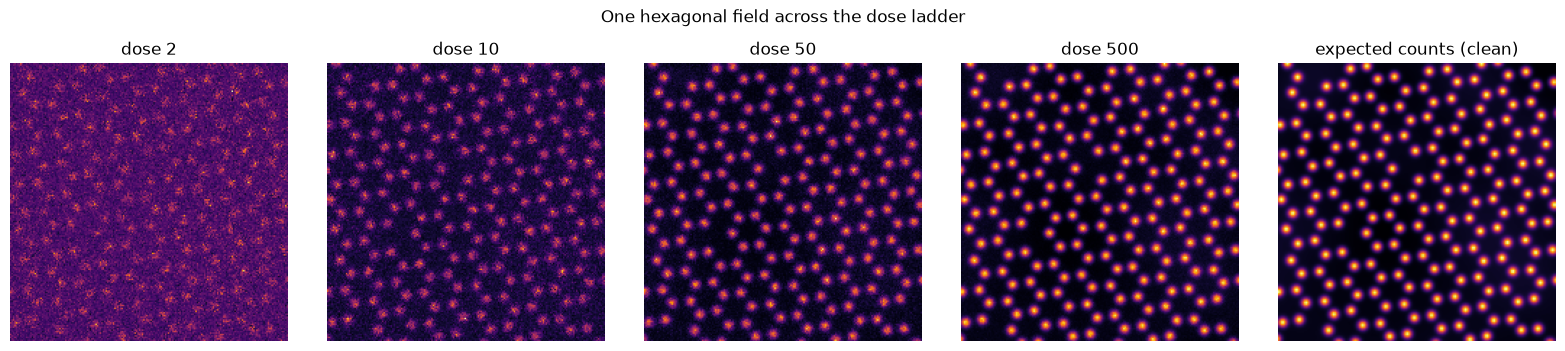

In [2]:
spec = preset("hexagonal")
field_rng = np.random.default_rng(42)
fld = make_field(field_rng, size=192, dose=1.0, spec=spec)  # unit intensity

doses = [2, 10, 50, 500]
fig, axes = plt.subplots(1, len(doses) + 1, figsize=(16, 3.4))
for ax, dose in zip(axes, doses):
    noisy = add_noise(dose * fld.clean, np.random.default_rng(dose))
    ax.imshow(noisy, cmap="inferno")
    ax.set_title(f"dose {dose}")
    ax.axis("off")
axes[-1].imshow(fld.clean, cmap="inferno")
axes[-1].set_title("expected counts (clean)")
axes[-1].axis("off")
fig.suptitle("One hexagonal field across the dose ladder", y=1.02)
plt.tight_layout()
plt.show()

## 2. Why classical denoisers need a variance-stabilizing transform

Poisson noise has variance equal to its mean, so bright columns are
noisier than vacuum in absolute terms. NLM and wavelet shrinkage assume
constant-variance Gaussian noise. The generalized Anscombe transform
fixes the mismatch: after `2*sqrt(x + 3/8 + sigma_r^2)` the noise is
close to unit variance at every brightness, and a bias-corrected inverse
maps the result back to counts. Every classical baseline in this
repository runs inside that transform, so the CNN is compared against
classical methods done properly, not against strawmen.

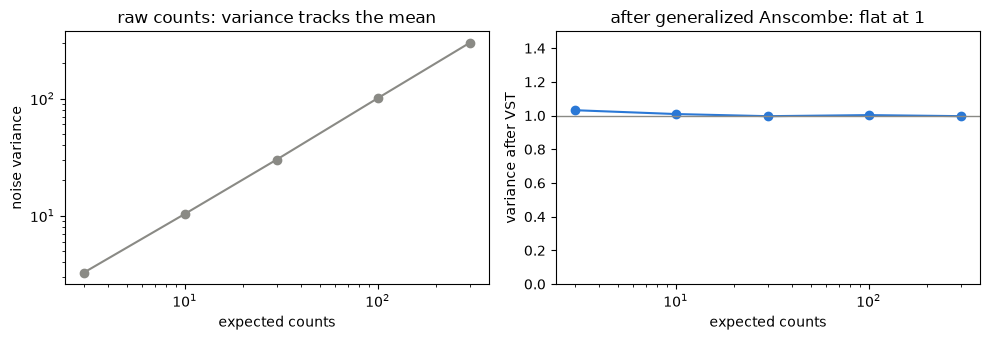

In [3]:
from stemdenoise.classical import anscombe

lams = [3, 10, 30, 100, 300]
raw_var, vst_var = [], []
check_rng = np.random.default_rng(1)
for lam in lams:
    x = check_rng.poisson(lam, 100_000) + check_rng.normal(scale=0.5, size=100_000)
    raw_var.append(x.var())
    vst_var.append(anscombe(x).var())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))
a1.plot(lams, raw_var, "o-", color="#8a8a85")
a1.set_xscale("log"); a1.set_yscale("log")
a1.set_xlabel("expected counts"); a1.set_ylabel("noise variance")
a1.set_title("raw counts: variance tracks the mean")
a2.plot(lams, vst_var, "o-", color="#2a78d6")
a2.axhline(1.0, color="#8a8a85", linewidth=1)
a2.set_ylim(0, 1.5)
a2.set_xscale("log")
a2.set_xlabel("expected counts"); a2.set_ylabel("variance after VST")
a2.set_title("after generalized Anscombe: flat at 1")
plt.tight_layout(); plt.show()

## 3. Restoration at dose 5: classical methods and the CNN

Dose 5 sits in the interesting band: too noisy to detect atoms reliably
from the raw frame, but restorable. The CNN below is the committed
range-trained checkpoint (`models/unet_supervised.pt`), a 0.26M-parameter
residual U-Net trained entirely on this simulator across doses 2 to 500.
The classical parameters are the ones the benchmark's per-dose tuning
selected, taken from `results/dose_sweep.json`.

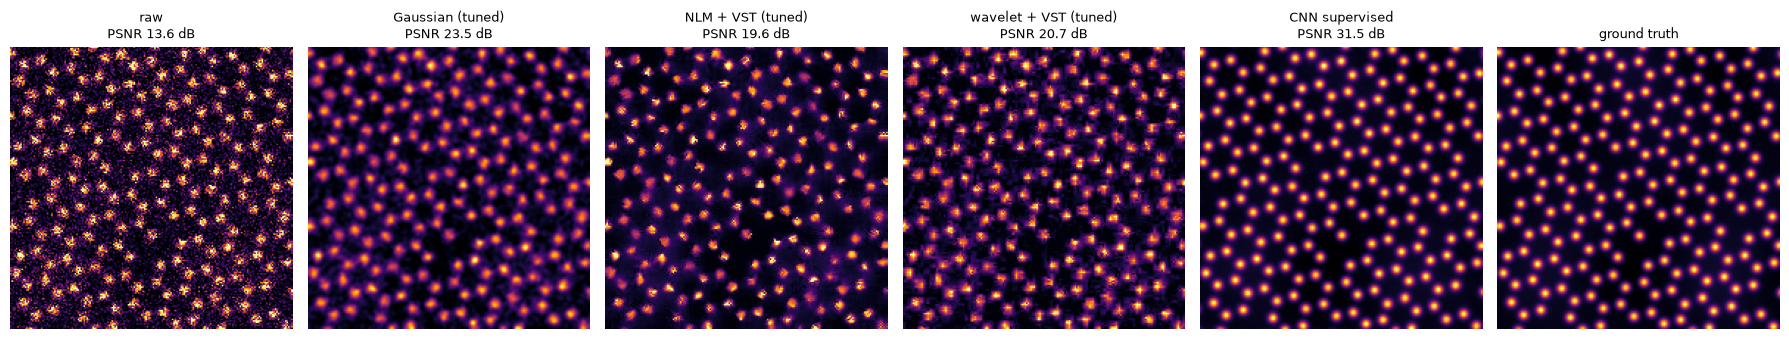

In [4]:
import json

DOSE = 5.0
fld5 = make_field(np.random.default_rng(7), size=192, dose=DOSE, spec=spec)
noisy5 = add_noise(fld5.clean, np.random.default_rng(8))

sweep = json.loads(Path("results/dose_sweep.json").read_text())["results"]
def tuned(method, dose=DOSE, preset_name="hexagonal"):
    row = next(r for r in sweep
               if r["method"] == method and r["dose"] == dose and r["preset"] == preset_name)
    return row.get("tuned_param")

model, meta = load_checkpoint("models/unet_supervised.pt")
restorations = {
    "raw": noisy5,
    "Gaussian (tuned)": gaussian_denoise(noisy5, sigma=tuned("gaussian")),
    "NLM + VST (tuned)": nlm_denoise(noisy5, h=tuned("nlm")),
    "wavelet + VST (tuned)": wavelet_denoise(noisy5, sigma_scale=tuned("wavelet")),
    "CNN supervised": denoise_counts(model, noisy5, dose=DOSE),
}

fig, axes = plt.subplots(1, len(restorations) + 1, figsize=(18, 3.4))
vmax = np.percentile(fld5.clean, 99.9)
for ax, (name, img) in zip(axes, restorations.items()):
    ax.imshow(img, cmap="inferno", vmin=0, vmax=vmax)
    ax.set_title(f"{name}\nPSNR {psnr(fld5.clean, img):.1f} dB", fontsize=9)
    ax.axis("off")
axes[-1].imshow(fld5.clean, cmap="inferno", vmin=0, vmax=vmax)
axes[-1].set_title("ground truth", fontsize=9)
axes[-1].axis("off")
plt.tight_layout(); plt.show()

## 4. Training is reproducible from scratch

The committed checkpoints come from `scripts/train_all.py` (fixed seeds,
about 30 minutes per range-trained model on CPU). To show the loop is
real, here is a deliberately tiny run: a small model, a few dozen steps,
just enough to watch the loss fall from its identity-initialized start.
The Noise2Noise variant uses a second independent noisy view as the
target instead of the clean image; its optimum is the same conditional
mean, which is why it works without any clean data.

[noise2noise d5-50] step 10/60 loss 0.03728 (2s)


[noise2noise d5-50] step 20/60 loss 0.02992 (4s)


[noise2noise d5-50] step 30/60 loss 0.02514 (5s)


[noise2noise d5-50] step 40/60 loss 0.02172 (7s)


[noise2noise d5-50] step 50/60 loss 0.02376 (8s)


[noise2noise d5-50] step 60/60 loss 0.02517 (10s)


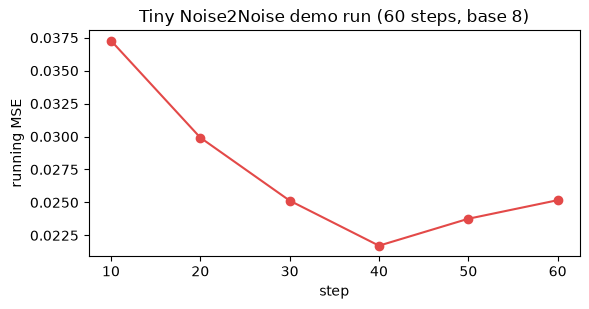

In [5]:
from stemdenoise import TrainConfig, train_denoiser

tiny = TrainConfig(mode="noise2noise", dose_min=5.0, dose_max=50.0,
                   steps=60, batch=8, patch=64, base=8, seed=0,
                   pool_fields=6, field_size=128)
_, tiny_hist = train_denoiser(tiny, log_every=10)

steps = [s for s, _ in tiny_hist]
losses = [v for _, v in tiny_hist]
plt.figure(figsize=(6, 3.2))
plt.plot(steps, losses, "o-", color="#e34948")
plt.xlabel("step"); plt.ylabel("running MSE")
plt.title("Tiny Noise2Noise demo run (60 steps, base 8)")
plt.tight_layout(); plt.show()

## 5. The metric that matters: can you still find the atoms?

PSNR rewards smoothness; microscopy rewards positions. A fixed, simple
peak finder (identical parameters for every method, derived from lattice
geometry alone) is applied to each restoration, and its output is matched
one-to-one against ground truth within 3 px. Border columns are excluded
on both sides.

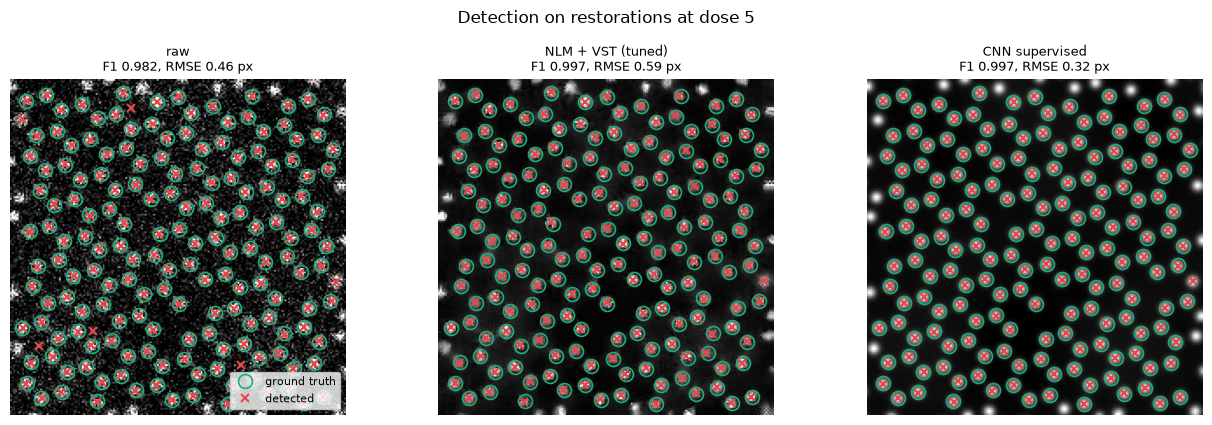

In [6]:
det_kw = detector_params_for(spec.spacing_px, spec.probe_sigma_px)
margin = spec.spacing_px / 2
shape = fld5.clean.shape
gt = filter_margin(fld5.positions, shape, margin)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, name in zip(axes, ["raw", "NLM + VST (tuned)", "CNN supervised"]):
    img = restorations[name]
    found = filter_margin(find_peaks(img, **det_kw), shape, margin)
    score = match_positions(gt, found, tolerance_px=3.0)
    ax.imshow(img, cmap="gray", vmin=0, vmax=vmax)
    ax.plot(gt[:, 1], gt[:, 0], "o", mfc="none", mec="#1baf7a",
            ms=10, mew=1.2, label="ground truth")
    if len(found):
        ax.plot(found[:, 1], found[:, 0], "x", color="#e34948", ms=6, mew=1.5, label="detected")
    ax.set_title(f"{name}\nF1 {score.f1:.3f}, RMSE {score.rmse_px:.2f} px", fontsize=9)
    ax.axis("off")
axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(f"Detection on restorations at dose {DOSE:g}", y=1.0)
plt.tight_layout(); plt.show()

## 6. The full benchmark, read from the committed results

`configs/dose_sweep.yaml` runs every method over seven doses and two
lattices with six evaluation fields per condition (plus separate tuning
fields for the classical methods). The committed JSON regenerates with
one command:

    stemdenoise benchmark configs/dose_sweep.yaml

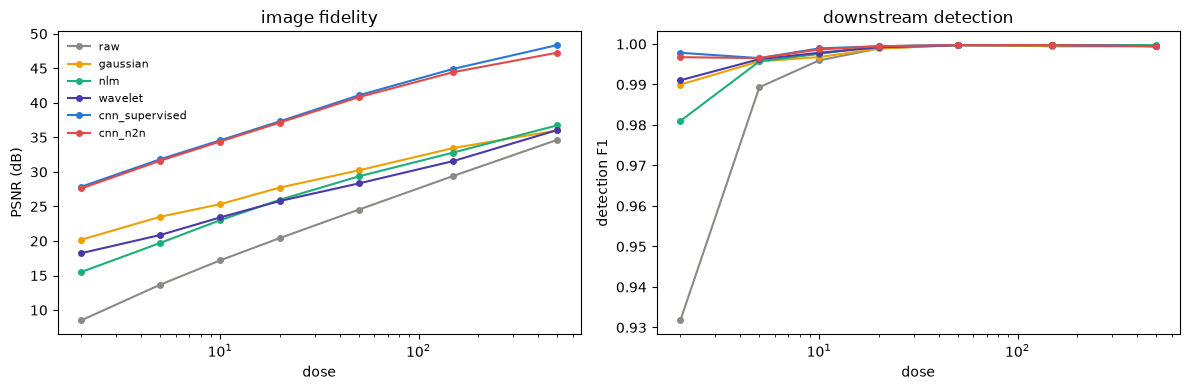

dose   2: best classical wavelet  F1 0.991 | CNN supervised F1 0.998 | Noise2Noise F1 0.997
dose   5: best classical wavelet  F1 0.996 | CNN supervised F1 0.997 | Noise2Noise F1 0.997
dose  10: best classical wavelet  F1 0.998 | CNN supervised F1 0.999 | Noise2Noise F1 0.999


In [7]:
rows = [r for r in sweep if r["preset"] == "hexagonal"]
methods = ["raw", "gaussian", "nlm", "wavelet", "cnn_supervised", "cnn_n2n"]
colors = {"raw": "#8a8a85", "gaussian": "#eda100", "nlm": "#1baf7a",
          "wavelet": "#4a3aa7", "cnn_supervised": "#2a78d6", "cnn_n2n": "#e34948"}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for m in methods:
    pts = sorted([(r["dose"], r["psnr"], r["f1"]) for r in rows if r["method"] == m])
    a1.plot([p[0] for p in pts], [p[1] for p in pts], "o-", color=colors[m], label=m, ms=4)
    a2.plot([p[0] for p in pts], [p[2] for p in pts], "o-", color=colors[m], label=m, ms=4)
a1.set_xscale("log"); a2.set_xscale("log")
a1.set_xlabel("dose"); a1.set_ylabel("PSNR (dB)"); a1.set_title("image fidelity")
a2.set_xlabel("dose"); a2.set_ylabel("detection F1"); a2.set_title("downstream detection")
a1.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

# The headline numbers, straight from the committed results.
for dose in (2, 5, 10):
    best_cl = max((r for r in rows if r["dose"] == dose
                   and r["method"] in ("gaussian", "nlm", "wavelet")), key=lambda r: r["f1"])
    cnn = next(r for r in rows if r["dose"] == dose and r["method"] == "cnn_supervised")
    n2n = next(r for r in rows if r["dose"] == dose and r["method"] == "cnn_n2n")
    print(f"dose {dose:>3}: best classical {best_cl['method']:<8} F1 {best_cl['f1']:.3f} | "
          f"CNN supervised F1 {cnn['f1']:.3f} | Noise2Noise F1 {n2n['f1']:.3f}")

## 7. What to take away

Read `RESULTS.md` for the full tables, including the binary lattice with
its faint sublattice and the cross-dose generalization check
(`configs/cross_dose.yaml`), which tests whether the CNN advantage is an
artifact of matched training dose. The short version of the findings,
each backed by a committed results file:

1. Fidelity and detection rank methods differently, and detection is the
   ranking a microscopist should care about.
2. Properly variance-stabilized classical methods are competitive at
   moderate and high dose; the learned models separate from them at the
   photon-starved end.
3. Noise2Noise, trained with no clean images at all, tracks the
   supervised model closely, which is the practically relevant result
   since real paired clean data barely exists.